# 01 — Data and exploratory analysis

**What this notebook establishes:** what the study is measured on, and one
property of the data — *autocorrelation* — that predicts, before any model is
fitted, which variables persistence will be almost impossible to beat on.

Every experiment in this study covers **13 ocean variables x 24 globally
distributed sites x 4 forecast horizons (1, 3, 7, 30 days)**, at daily
resolution over 2024-06-11 to 2026-08-09.

### Running this
No credentials and no network are needed. The cleaned point series is committed
to `research/data/point_series.parquet` (3.1 MB), exported once by
`backend/scripts/export_research_dataset.py`. Notebooks 01-03 read only that
file; notebook 04 additionally reads the committed experiment output.

Run in order: **01 -> 02 -> 03 -> 04**.

In [1]:
import marisviz as mv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mv.setup()   # high-resolution, study-consistent matplotlib configuration

series = mv.load_series()
variables = mv.load_variables()
sites = mv.load_sites()

print(f"{len(series):,} rows | {series['variable'].nunique()} variables "
      f"| {series['site'].nunique()} sites")
print(f"{series['timestamp'].min():%Y-%m-%d} to {series['timestamp'].max():%Y-%m-%d}")

988,872 rows | 13 variables | 24 sites
2024-06-11 to 2026-08-10


## The variables

One framework serves all thirteen; nothing in the pipeline branches on which
variable it is training. `code` is the field fetched from the provider,
`covariates` are the additional fields used as predictors, and `circular` marks
bearings, where 359 deg and 1 deg are neighbours.

In [2]:
variables[["variable", "unit", "category", "circular", "log_transform",
           "target_mode", "sites"]]

,variable,unit,category,circular,log_transform,target_mode,sites
0,water_temperature,degC,Temperature,False,False,delta,24
1,bottom_temperature,degC,Temperature,False,False,delta,24
2,water_salinity,PSU,Salinity,False,False,delta,24
3,significant_wave_height,m,Waves,False,False,delta,24
4,maximum_wave_height,m,Waves,False,False,delta,24
5,mean_wave_period,s,Waves,False,False,delta,24
6,wave_direction,deg,Waves,True,False,delta,24
7,sea_level_anomaly,m,Sea Level,False,False,delta,24
8,chlorophyll_a,mg/m3,Ocean Colour,False,True,delta,24
9,dissolved_oxygen,mmol/m3,Biogeochemistry,False,False,delta,24


## Where the sites are

Chosen to span dynamical regimes, not just to spread over the map: western
boundary currents (Gulf Stream, Kuroshio, Agulhas), eastern boundary upwelling
systems (Peru, Benguela, Canary), subtropical gyres, marginal and shelf seas,
and the Southern Ocean. Notebook 04 shows that *which regime a site belongs to*
predicts how well a model transfers to it.

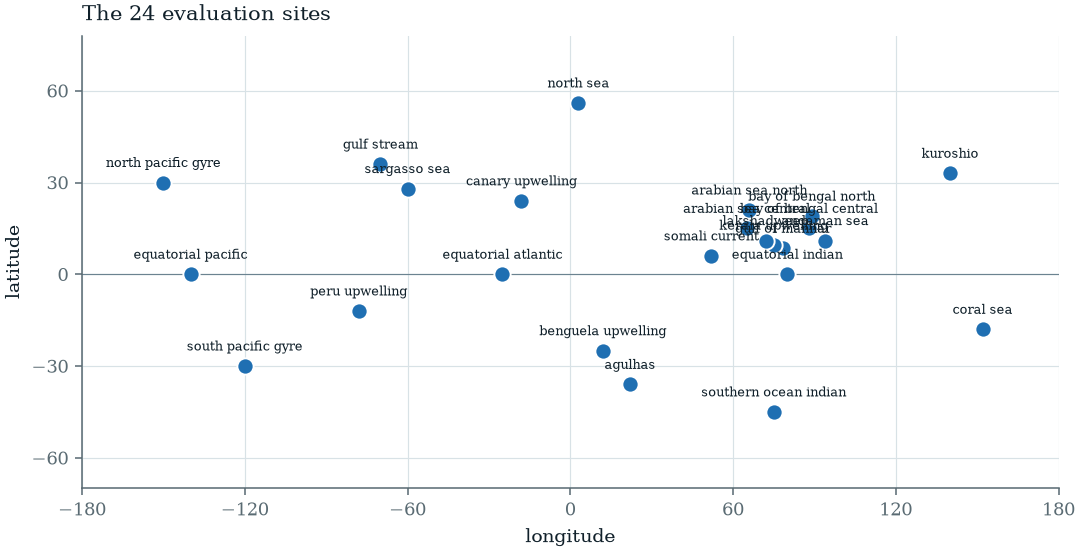

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(sites["longitude"], sites["latitude"], s=70, color=mv.PERSISTENCE,
           edgecolor="white", linewidth=1.0, zorder=3)
for _, r in sites.iterrows():
    ax.annotate(mv.pretty(r["site"]), (r["longitude"], r["latitude"]),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=6.5, color=mv.INK)
ax.axhline(0, color=mv.MUTED, linewidth=0.6, zorder=1)
ax.set(xlim=(-180, 180), ylim=(-70, 78), xlabel="longitude", ylabel="latitude",
       xticks=range(-180, 181, 60), yticks=range(-60, 79, 30),
       title="The 24 evaluation sites")
mv.save(fig, "01_sites")
plt.show()

## Coverage

Coverage is not identical across variables — sea level anomaly is a shorter
product than the physics fields. Reporting it rather than assuming uniformity
matters, because a skill score computed on a shorter record is a different
measurement.

In [4]:
target = series[series["role"] == "target"]
coverage = (target.groupby("variable", observed=True)
            .agg(sites=("site", "nunique"),
                 start=("timestamp", "min"),
                 end=("timestamp", "max"),
                 observations=("value", "size"),
                 missing=("value", lambda s: float(s.isna().mean() * 100)))
            .assign(days=lambda d: (d["end"] - d["start"]).dt.days)
            .round({"missing": 2}))
coverage[["sites", "start", "end", "days", "observations", "missing"]]

,sites,start,end,days,observations,missing
variable,,,,,,
bottom_temperature,24,2024-06-11,2026-08-10,790,18984,0.0
chlorophyll_a,24,2024-06-11,2026-08-10,790,18984,0.0
dissolved_oxygen,24,2024-06-11,2026-08-10,790,18984,0.0
maximum_wave_height,24,2024-06-13,2026-08-09,787,18912,0.0
mean_wave_period,24,2024-06-13,2026-08-09,787,18912,0.0
nitrate,24,2024-06-11,2026-08-10,790,18984,0.0
ph,24,2024-06-11,2026-08-10,790,18984,0.0
primary_productivity,24,2024-06-11,2026-08-10,790,18984,0.0
sea_level_anomaly,24,2025-06-11,2026-08-10,425,10224,0.0


## What the series look like

Four sites of sea-surface water temperature, spanning the latitude range. The
annual cycle dominates at high latitude and nearly vanishes at the equator —
the first hint that a *seasonal* baseline will be strong in some places and
weak in others.

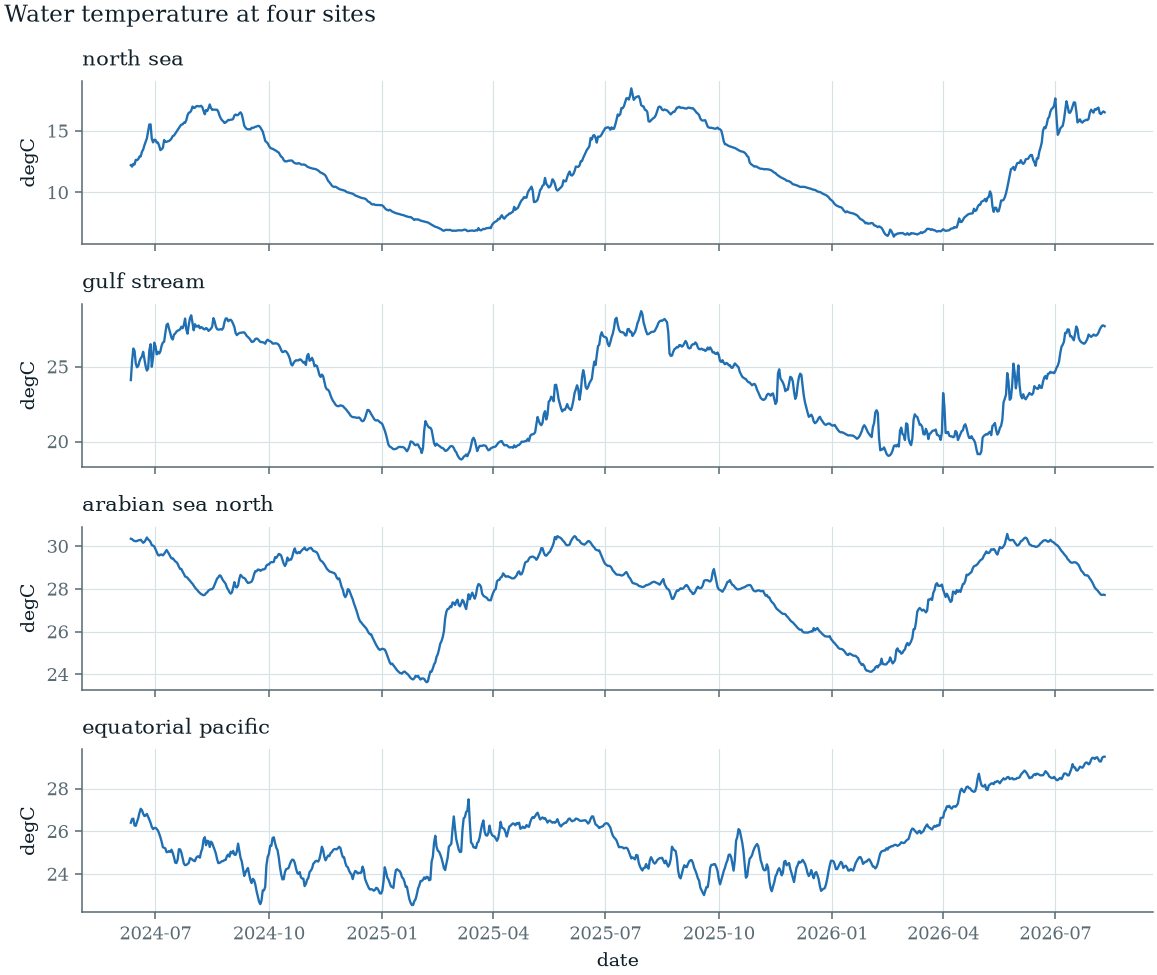

In [5]:
panel = mv.target_panel(series, "water_temperature")
chosen = ["north_sea", "gulf_stream", "arabian_sea_north", "equatorial_pacific"]
chosen = [c for c in chosen if c in panel.columns]

fig, axes = plt.subplots(len(chosen), 1, figsize=(8.4, 7.2), sharex=True)
for ax, site in zip(axes, chosen):
    ax.plot(panel.index, panel[site], color=mv.PERSISTENCE, linewidth=1.2)
    ax.set_title(mv.pretty(site))
    ax.set_ylabel("degC")
axes[-1].set_xlabel("date")
fig.suptitle("Water temperature at four sites", x=0.005, ha="left", fontsize=12)
fig.tight_layout()
mv.save(fig, "01_series")
plt.show()

## Seasonal structure

The day-of-year mean per site — the shape the climatology baseline in notebook
03 estimates. Note the amplitude difference: where this curve is flat, a
seasonal baseline carries almost no information.

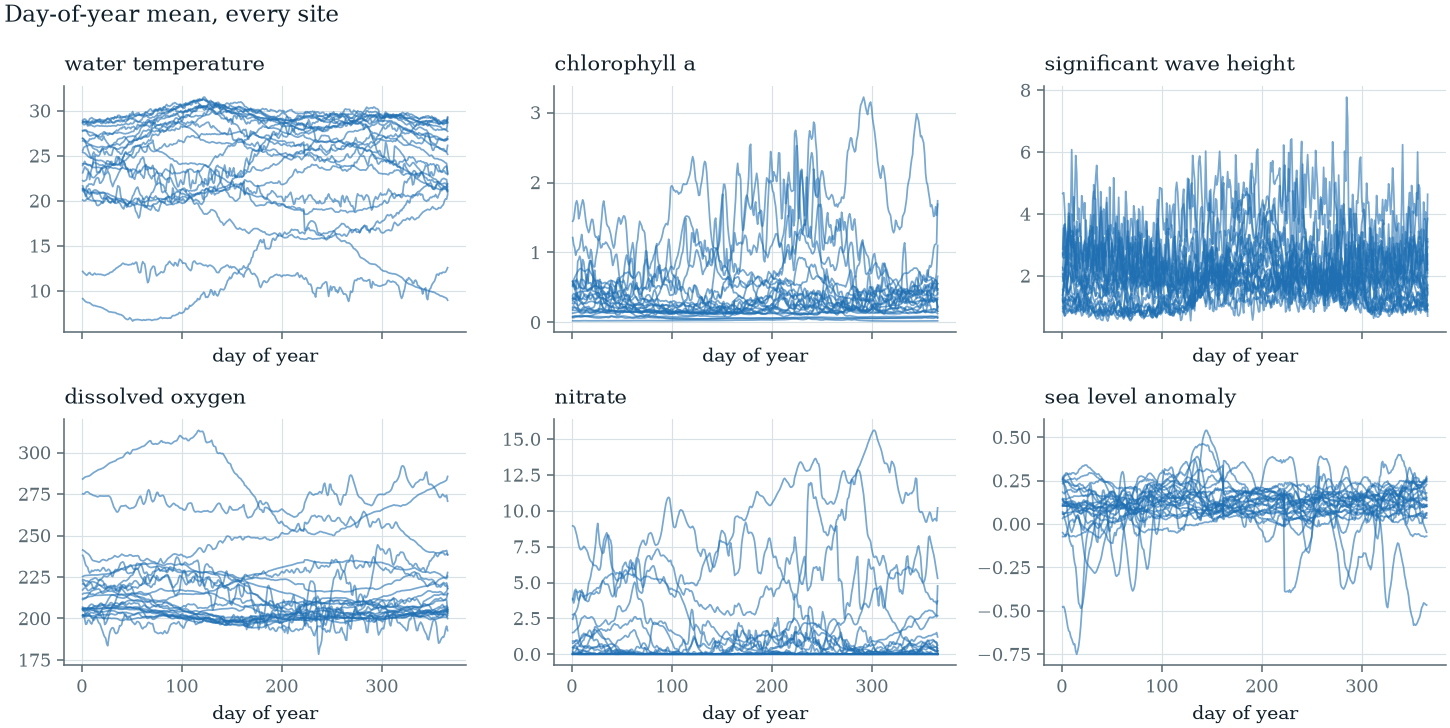

In [6]:
show = ["water_temperature", "chlorophyll_a", "significant_wave_height",
        "dissolved_oxygen", "nitrate", "sea_level_anomaly"]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.4), sharex=True)
for ax, var in zip(axes.ravel(), show):
    p = mv.target_panel(series, var)
    doy = p.groupby(p.index.dayofyear).mean()
    for site in p.columns:
        ax.plot(doy.index, doy[site], linewidth=0.9, alpha=0.6, color=mv.PERSISTENCE)
    ax.set_title(mv.pretty(var))
    ax.set_xlabel("day of year")
fig.suptitle("Day-of-year mean, every site", x=0.005, ha="left", fontsize=12)
fig.tight_layout()
mv.save(fig, "01_seasonality")
plt.show()

## Autocorrelation — the diagnostic that predicts the results

This is the most important figure in this notebook.

Persistence forecasts $\hat{y}(t+h) = y(t)$. Its error is therefore governed
entirely by how fast the series decorrelates from itself. A variable whose
autocorrelation is still near 1.0 at lag 30 is one where **persistence is close
to optimal**, and where a model has almost no room to add value — the residual
it is asked to predict is nearly pure noise.

Watch `bottom_temperature` and `water_salinity`.

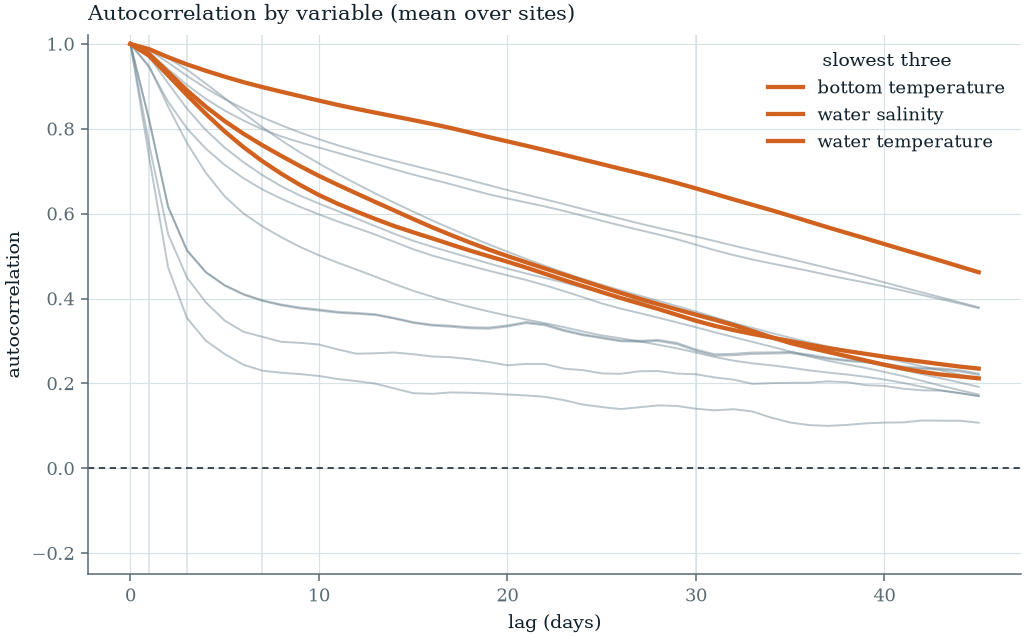

In [7]:
MAX_LAG = 45
acf = {}
for var in sorted(target["variable"].unique()):
    p = mv.target_panel(series, var)
    # Averaged over sites: each site contributes its own ACF, so one
    # long-memory site cannot stand in for the whole variable.
    acf[var] = np.nanmean([mv.autocorrelation(p[s], MAX_LAG) for s in p.columns], axis=0)
acf = pd.DataFrame(acf, index=range(MAX_LAG + 1))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
slow = ["bottom_temperature", "water_salinity", "water_temperature"]
for var in acf.columns:
    hi = var in slow
    ax.plot(acf.index, acf[var],
            color=mv.CLIMATOLOGY if hi else mv.MUTED,
            linewidth=2.2 if hi else 1.0, alpha=1.0 if hi else 0.45,
            zorder=3 if hi else 2, label=mv.pretty(var) if hi else None)
ax.axhline(0, color=mv.INK, linewidth=0.8, linestyle=(0, (4, 3)))
for h in (1, 3, 7, 30):
    ax.axvline(h, color=mv.RULE, linewidth=0.8, zorder=1)
ax.set(xlabel="lag (days)", ylabel="autocorrelation", ylim=(-0.25, 1.02),
       title="Autocorrelation by variable (mean over sites)")
ax.legend(title="slowest three")
mv.save(fig, "01_acf")
plt.show()

In [8]:
# Autocorrelation at exactly the four forecast horizons. Read this as
# "how good is persistence, for free" -- the closer to 1.0, the harder it is to
# beat, and the smaller the signal left for a model to find.
at_h = acf.loc[[1, 3, 7, 30]].T
at_h.columns = [f"lag {h}" for h in (1, 3, 7, 30)]
at_h.sort_values("lag 30", ascending=False).round(3)

,lag 1,lag 3,lag 7,lag 30
water_temperature,0.988,0.952,0.898,0.660
ph,0.986,0.925,0.827,0.546
dissolved_oxygen,0.979,0.903,0.799,0.527
sea_level_anomaly,0.986,0.939,0.804,0.370
chlorophyll_a,0.969,0.847,0.691,0.365
bottom_temperature,0.976,0.891,0.761,0.362
water_salinity,0.972,0.880,0.724,0.348
primary_productivity,0.944,0.801,0.657,0.332
significant_wave_height,0.819,0.514,0.396,0.280
maximum_wave_height,0.819,0.513,0.395,0.277


**Read the last column.** `bottom_temperature` retains ~0.9
autocorrelation at 30 days and `water_salinity` is close behind. Where
persistence is this strong, the headroom above it is small: the residual a
model is asked to predict is close to pure noise, and fitting it risks adding
variance without adding signal.

That makes these two the **variables most at risk** of scoring below
persistence — and notebook 04 shows both of them do.

Stated carefully, though, this is a *hypothesis to test*, not a law. High
autocorrelation implies a strong baseline; it does not by itself imply the
model must lose. `water_temperature` is also strongly autocorrelated and goes
on to score well. Notebook 04 tests the relationship across all 52
model-horizon pairs and finds it **does not hold in general** — which is worth
knowing, because "just check the autocorrelation" is exactly the shortcut one
would otherwise be tempted to adopt.

## Distributions

Several biogeochemical variables are strongly right-skewed and span orders of
magnitude. That is what the `log_transform` flag is for: in log space the model
learns a *ratio* of change, which is the right scale when a 0.5 mg/m^3 rise
means something completely different in a gyre than in an upwelling.

In [9]:
skew = (target.dropna(subset=["value"])
        .groupby("variable", observed=True)["value"]
        .agg(skew="skew", minimum="min", median="median", maximum="max")
        .join(variables.set_index("variable")[["log_transform", "unit"]])
        .sort_values("skew", ascending=False).round(3))
skew

,skew,minimum,median,maximum,log_transform,unit
variable,,,,,,
chlorophyll_a,3.513,0.018,0.228,5.089,True,mg/m3
primary_productivity,3.449,0.057,10.320,251.411,True,mg/m3/day
nitrate,2.717,0.000,0.023,17.467,True,mmol/m3
bottom_temperature,1.911,0.762,2.398,15.756,False,degC
dissolved_oxygen,1.845,167.540,207.511,314.113,False,mmol/m3
significant_wave_height,1.477,0.308,1.825,9.498,False,m
maximum_wave_height,1.429,0.572,3.439,17.346,False,m
mean_wave_period,0.676,2.928,6.069,12.491,False,s
wave_direction,-0.179,2.496,188.203,358.208,False,deg


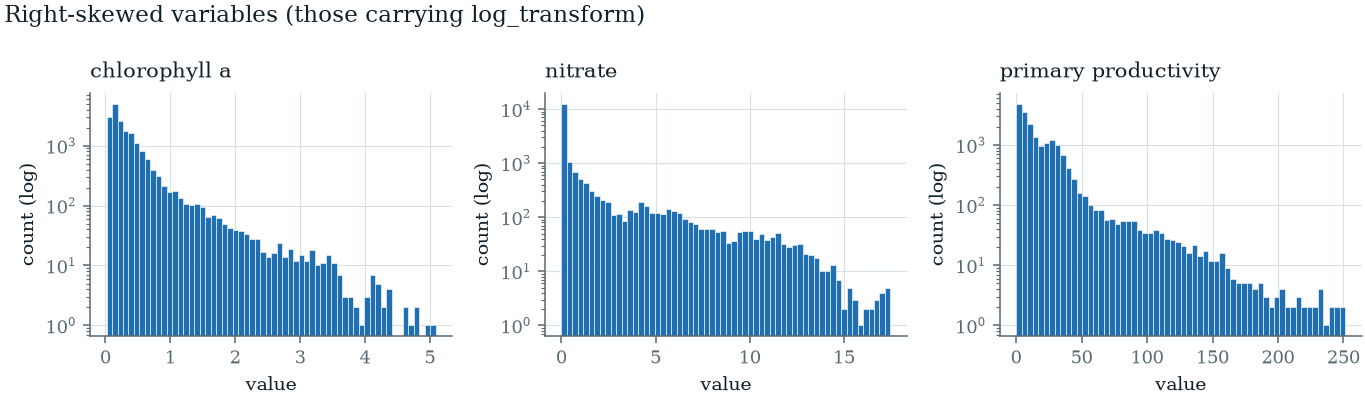

In [10]:
logged = variables.loc[variables["log_transform"], "variable"].tolist()
if logged:
    fig, axes = plt.subplots(1, len(logged), figsize=(3.3 * len(logged), 3.0))
    for ax, var in zip(np.atleast_1d(axes), logged):
        v = target.loc[target["variable"] == var, "value"].dropna()
        ax.hist(v, bins=60, color=mv.PERSISTENCE, edgecolor="white", linewidth=0.3)
        ax.set(title=mv.pretty(var), yscale="log", xlabel="value", ylabel="count (log)")
    fig.suptitle("Right-skewed variables (those carrying log_transform)",
                 x=0.005, ha="left", fontsize=12)
    fig.tight_layout()
    mv.save(fig, "01_distributions")
    plt.show()
else:
    print("no log-transformed variables in this set")

## Takeaways

1. **13 variables x 24 sites x ~800 daily timesteps**, with coverage that
   genuinely differs by variable and is reported rather than assumed.
2. **Seasonal amplitude varies enormously by variable and site.** Where the
   day-of-year curve is flat, a climatology baseline is weak; where it is
   strong, climatology is the baseline to beat.
3. **Autocorrelation identifies where persistence is hard to beat.**
   Variables still correlated ~0.9 at lag 30 (`bottom_temperature`,
   `water_salinity`) leave little headroom, and both do go on to fail in
   notebook 04 — but the relationship is not general, and notebook 04 measures
   exactly how far it does and does not hold.

Next: **02 — feature engineering**, including the target formulation the whole
framework turns on.